In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50, DenseNet121
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = "/content/drive/MyDrive/chest_xray"

train_dir = data_path + "/train"
test_dir  = data_path + "/test"

In [4]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
def build_model(base_model):
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
model1 = build_model(
    MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
)

history1 = model1.fit(train_data, validation_data=val_data, epochs=5)

loss1, acc1 = model1.evaluate(test_data)
print("MobileNetV2 Accuracy:", acc1)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 3905s 30s/step - accuracy: 0.9305 - loss: 0.1746 - val_accuracy: 0.9464 - val_loss: 0.1301
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 994ms/step - accuracy: 0.9503 - loss: 0.1299 - val_accuracy: 0.9512 - val_loss: 0.1189
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 998ms/step - accuracy: 0.9546 - loss: 0.1196 - val_accuracy: 0.9522 - val_loss: 0.1097
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 992ms/step - accuracy: 0.9529 - loss: 0.1232 - val_accuracy: 0.9158 - val_loss: 0.1894
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 982ms/step - accuracy: 0.9608 - loss: 0.1049 - val_accuracy: 0.9636 - val_loss: 0.1039
20/20 ━━━━━━━━━━━━━━━━━━━━ 438s 22s/step - accuracy: 0.9087 - loss: 0.2413
MobileNetV2 Accuracy: 0.9086538553237915


In [8]:
model2 = build_model(
    VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
)

history2 = model2.fit(train_data, validation_data=val_data, epochs=5)

loss2, acc2 = model2.evaluate(test_data)
print("VGG16 Accuracy:", acc2)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.8020 - loss: 0.4088 - val_accuracy: 0.9081 - val_loss: 0.2534
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9045 - loss: 0.2411 - val_accuracy: 0.9072 - val_loss: 0.2191
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9147 - loss: 0.2156 - val_accuracy: 0.9072 - val_loss: 0.2147
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9236 - loss: 0.1930 - val_accuracy: 0.9340 - val_loss: 0.1790
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9272 - loss: 0.1868 - val_accuracy: 0.9282 - val_loss: 0.1802
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9054 - loss: 0.2478
VGG16 Accuracy: 0.9054487347602844


In [9]:
model3 = build_model(
    ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
)

history3 = model3.fit(train_data, validation_data=val_data, epochs=5)

loss3, acc3 = model3.evaluate(test_data)
print("ResNet50 Accuracy:", acc3)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.7444 - loss: 0.5469 - val_accuracy: 0.7445 - val_loss: 0.5136
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.7583 - loss: 0.4755 - val_accuracy: 0.7990 - val_loss: 0.4418
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7839 - loss: 0.4518 - val_accuracy: 0.8153 - val_loss: 0.4138
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8058 - loss: 0.4036 - val_accuracy: 0.8421 - val_loss: 0.3785
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8113 - loss: 0.3904 - val_accuracy: 0.8211 - val_loss: 0.3617
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 641ms/step - accuracy: 0.7516 - loss: 0.4724
ResNet50 Accuracy: 0.7516025900840759


In [10]:
model4 = build_model(
    DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
)

history4 = model4.fit(train_data, validation_data=val_data, epochs=5)

loss4, acc4 = model4.evaluate(test_data)
print("DenseNet121 Accuracy:", acc4)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.8834 - loss: 0.2847 - val_accuracy: 0.9177 - val_loss: 0.1916
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9334 - loss: 0.1734 - val_accuracy: 0.9311 - val_loss: 0.1722
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9298 - loss: 0.1681 - val_accuracy: 0.9474 - val_loss: 0.1445
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9451 - loss: 0.1458 - val_accuracy: 0.9512 - val_loss: 0.1337
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 131s 996ms/step - accuracy: 0.9475 - loss: 0.1342 - val_accuracy: 0.9541 - val_loss: 0.1246
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9087 - loss: 0.2019
DenseNet121 Accuracy: 0.9086538553237915


In [11]:
print("\nFinal Comparison:")
print("MobileNetV2:", acc1)
print("VGG16:", acc2)
print("ResNet50:", acc3)
print("DenseNet121:", acc4)


Final Comparison:
MobileNetV2: 0.9086538553237915
VGG16: 0.9054487347602844
ResNet50: 0.7516025900840759
DenseNet121: 0.9086538553237915


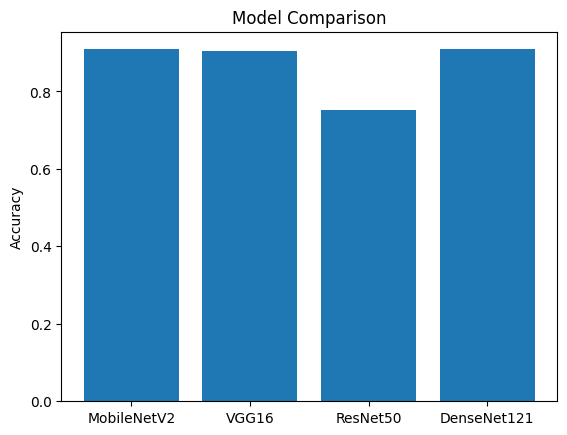

In [12]:
models_names = ['MobileNetV2', 'VGG16', 'ResNet50', 'DenseNet121']
accuracies = [acc1, acc2, acc3, acc4]

plt.bar(models_names, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [17]:
!pip install gradio

In [19]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

# دالة التوقع
def predict_all_models(img):
    img = img.resize((224,224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    results = ""

    models_list = {
        "MobileNetV2": model1,
        "VGG16": model2,
        "ResNet50": model3,
        "DenseNet121": model4
    }

    for name, model in models_list.items():
        pred = model.predict(img_array)
        result = "Pneumonia" if pred[0][0] > 0.5 else "Normal"
        results += f"{name}: {result}\n"

    return results

interface = gr.Interface(
    fn=predict_all_models,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Pneumonia Detection (Multi-Model)",
    description="Upload X-ray image to compare predictions"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bb959af904098c372.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
